# 🧪 Lab Session: Regularization in Logistic Regression
## Pima Indians Diabetes Dataset — With & Without Regularization

---

**Objectives:**
- Understand why regularization is needed in logistic regression
- Compare unregularized vs. L1 and L2 regularized models
- Tune the regularization strength `C` via cross-validation
- Interpret the effect of regularization on model coefficients

**Estimated time:** 90 minutes  
**Dataset:** [Pima Indians Diabetes Dataset](https://www.kaggle.com/uciml/pima-indians-diabetes-database) (768 samples, 8 features)

---

## 0. Environment Setup

Install and import all required libraries.

In [2]:
# Install if needed (uncomment)
# !pip install pandas numpy scikit-learn matplotlib seaborn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline

# Reproducibility
np.random.seed(42)

# Nicer plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 1. Load and Explore the Dataset

The **Pima Indians Diabetes Dataset** contains medical diagnostic measurements for female patients of Pima Indian heritage. The task is to predict whether a patient has diabetes.

| Feature | Description |
|---|---|
| Pregnancies | Number of times pregnant |
| Glucose | Plasma glucose concentration (2-hour OGTT) |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin fold thickness (mm) |
| Insulin | 2-hour serum insulin (mu U/ml) |
| BMI | Body mass index (weight/height²) |
| DiabetesPedigreeFunction | Diabetes pedigree function (genetic risk) |
| Age | Age (years) |
| Outcome | **Target** — 1 = diabetic, 0 = non-diabetic |

In [3]:
# Load dataset directly from OpenML / URL
url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
df = pd.read_csv(url)

print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
df.head()

Shape: (768, 9)

Column names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Basic statistics
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [5]:
# Check class balance
print('Class distribution:')
print(df['Outcome'].value_counts())
print(f'\nClass ratio: {df["Outcome"].mean():.1%} positive (diabetic)')

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class ratio: 34.9% positive (diabetic)


## 2. Data Preprocessing

### 2.1 Handle Zero Values
Several features contain zeros that represent **missing data** (e.g., a BMI of 0 is physically impossible). We'll replace these with the column median.

In [6]:
# Columns where 0 is biologically impossible
zero_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Count zeros
print('Zero counts before imputation:')
for col in zero_invalid:
    n = (df[col] == 0).sum()
    print(f'  {col}: {n} zeros ({n/len(df):.1%})')

# Replace with median (robust to remaining zeros in that column)
df_clean = df.copy()
for col in zero_invalid:
    median_val = df_clean[df_clean[col] != 0][col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)

print('\n✅ Zero values replaced with column medians')

Zero counts before imputation:
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)

✅ Zero values replaced with column medians


### 2.2 Split Features and Target

In [7]:
FEATURES = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
TARGET = 'Outcome'

X = df_clean[FEATURES].values
y = df_clean[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 614 samples
Test set:     154 samples


### 2.3 Feature Scaling

> ⚠️ **Critical:** Regularization penalizes large coefficient values. If features are on very different scales, the penalty will be applied inconsistently. **Always standardize before applying regularized logistic regression.**

We fit the scaler on training data only to prevent data leakage.

In [8]:
scaler = StandardScaler()

# Fit ONLY on training data — avoid data leakage!
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # use training statistics

print('Feature means after scaling (should be ≈ 0):')
print(X_train_scaled.mean(axis=0).round(3))
print('\nFeature stds after scaling (should be ≈ 1):')
print(X_train_scaled.std(axis=0).round(3))

Feature means after scaling (should be ≈ 0):
[-0. -0.  0. -0.  0.  0.  0. -0.]

Feature stds after scaling (should be ≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1.]


## 3. Exploratory Data Analysis

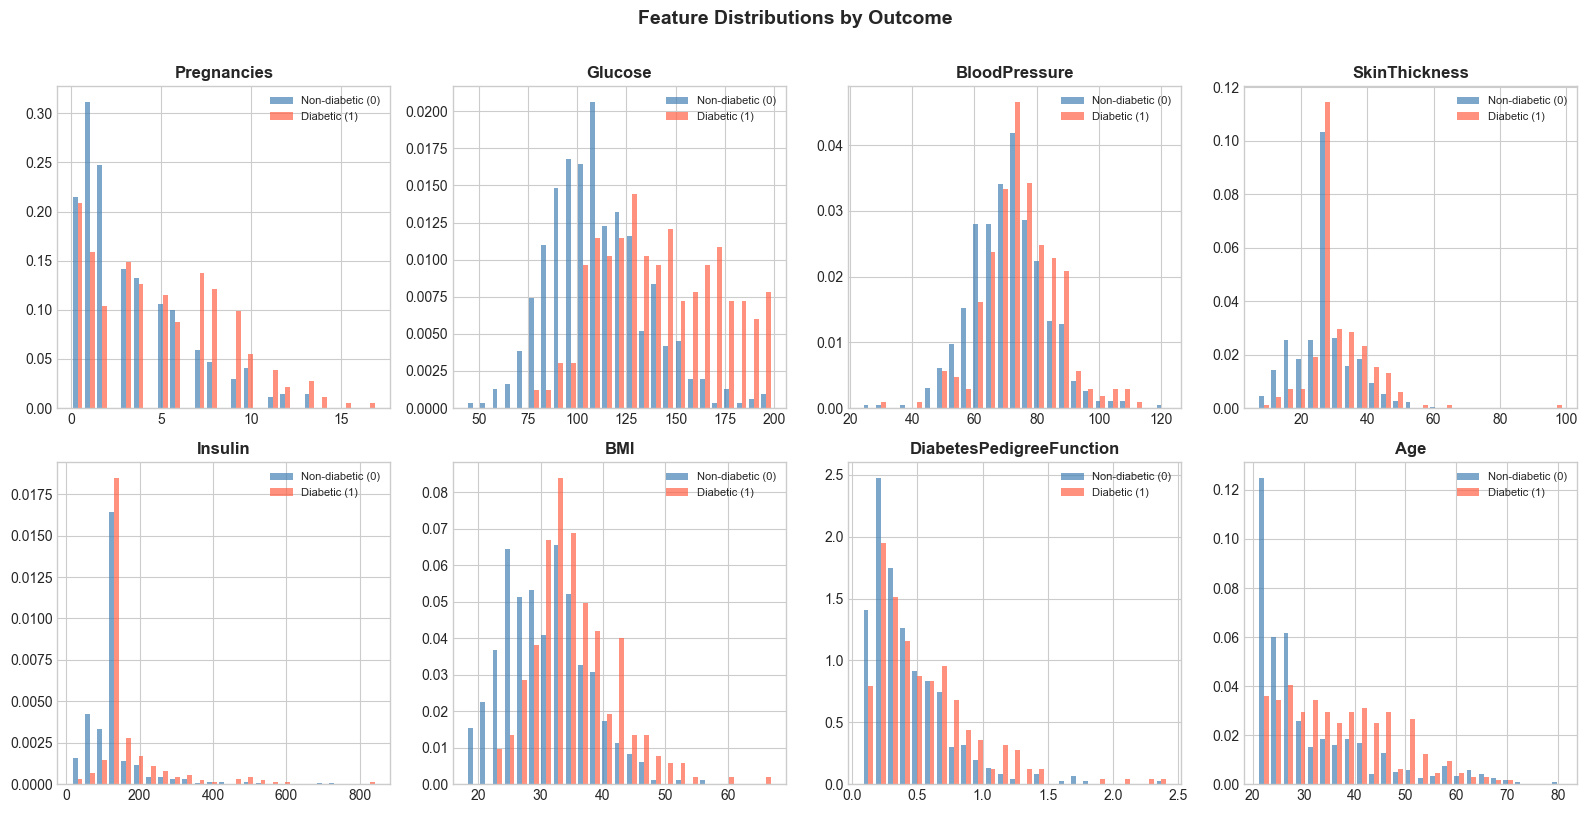

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    axes[i].hist(
        [df_clean[df_clean.Outcome==0][col], df_clean[df_clean.Outcome==1][col]],
        bins=25, label=['Non-diabetic (0)', 'Diabetic (1)'],
        color=['steelblue', 'tomato'], alpha=0.7, density=True
    )
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Outcome', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

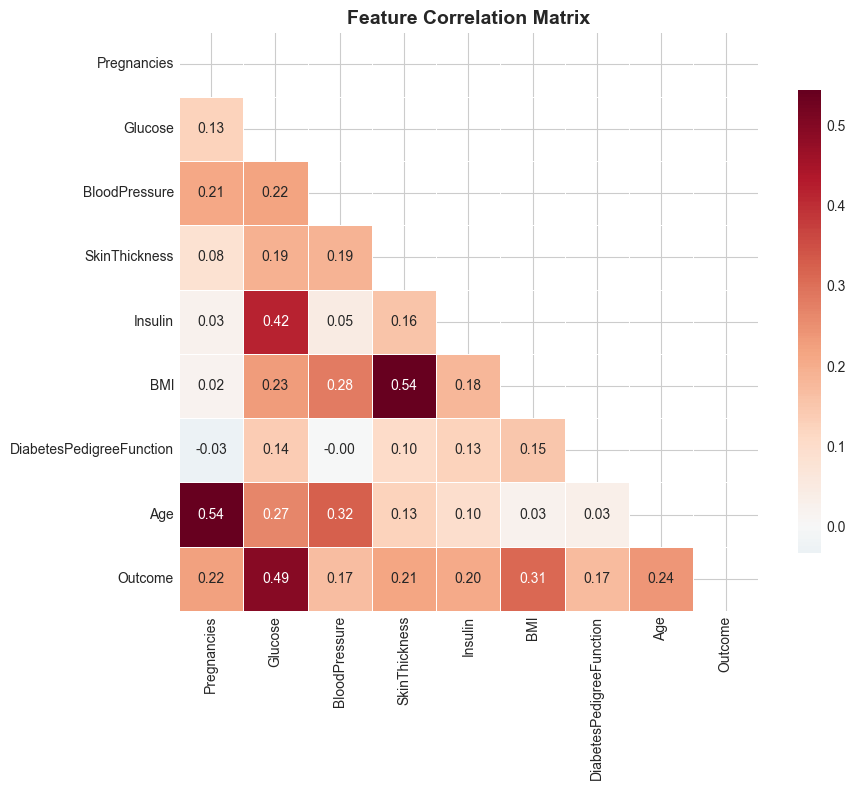

Glucose and BMI appear to have the highest correlation with the Outcome.


In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df_clean[FEATURES + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Glucose and BMI appear to have the highest correlation with the Outcome.')

## 4. Model Without Regularization

We use a very large `C` value (C = 1e9) to effectively disable regularization. This is equivalent to standard maximum likelihood logistic regression.

> **Note:** Setting `penalty='none'` or `C=1e9` achieves the same effect.

In [11]:
# Unregularized logistic regression
model_no_reg = LogisticRegression(
    penalty='l2',      # penalty still set but made negligible by large C
    C=1e9,             # C = 1/λ → very large C = very small penalty
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model_no_reg.fit(X_train_scaled, y_train)

y_pred_no_reg = model_no_reg.predict(X_test_scaled)
y_prob_no_reg = model_no_reg.predict_proba(X_test_scaled)[:, 1]

acc_no_reg = accuracy_score(y_test, y_pred_no_reg)
auc_no_reg = roc_auc_score(y_test, y_prob_no_reg)

# Cross-validation score
cv_no_reg = cross_val_score(
    model_no_reg, X_train_scaled, y_train, cv=5, scoring='roc_auc'
)

print('=== No Regularization (C=1e9) ===')
print(f'Test Accuracy : {acc_no_reg:.4f}')
print(f'Test AUC      : {auc_no_reg:.4f}')
print(f'CV AUC        : {cv_no_reg.mean():.4f} ± {cv_no_reg.std():.4f}')
print('\nCoefficients:')
for feat, coef in zip(FEATURES, model_no_reg.coef_[0]):
    print(f'  {feat:30s}: {coef:+.4f}')

=== No Regularization (C=1e9) ===
Test Accuracy : 0.7078
Test AUC      : 0.8131
CV AUC        : 0.8427 ± 0.0293

Coefficients:
  Pregnancies                   : +0.3861
  Glucose                       : +1.2068
  BloodPressure                 : -0.0504
  SkinThickness                 : +0.0217
  Insulin                       : -0.0761
  BMI                           : +0.7056
  DiabetesPedigreeFunction      : +0.2368
  Age                           : +0.1460


In [12]:
print('Classification Report — No Regularization:')
print(classification_report(y_test, y_pred_no_reg, target_names=['Non-diabetic', 'Diabetic']))

Classification Report — No Regularization:
              precision    recall  f1-score   support

Non-diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



## 5. Model With L2 Regularization (Ridge)

L2 regularization (the default in scikit-learn) adds a penalty of λ·Σβᵢ² to the loss function. It shrinks all coefficients toward zero but doesn't eliminate any.

We'll first try the default `C=1.0`, then find the optimal C via cross-validation.

In [13]:
# L2 with default C=1.0
model_l2 = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model_l2.fit(X_train_scaled, y_train)

y_pred_l2 = model_l2.predict(X_test_scaled)
y_prob_l2 = model_l2.predict_proba(X_test_scaled)[:, 1]

acc_l2 = accuracy_score(y_test, y_pred_l2)
auc_l2 = roc_auc_score(y_test, y_prob_l2)
cv_l2 = cross_val_score(model_l2, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print('=== L2 Regularization (C=1.0) ===')
print(f'Test Accuracy : {acc_l2:.4f}')
print(f'Test AUC      : {auc_l2:.4f}')
print(f'CV AUC        : {cv_l2.mean():.4f} ± {cv_l2.std():.4f}')
print('\nCoefficients:')
for feat, coef in zip(FEATURES, model_l2.coef_[0]):
    print(f'  {feat:30s}: {coef:+.4f}')

=== L2 Regularization (C=1.0) ===
Test Accuracy : 0.7078
Test AUC      : 0.8130
CV AUC        : 0.8432 ± 0.0293

Coefficients:
  Pregnancies                   : +0.3775
  Glucose                       : +1.1825
  BloodPressure                 : -0.0441
  SkinThickness                 : +0.0282
  Insulin                       : -0.0662
  BMI                           : +0.6887
  DiabetesPedigreeFunction      : +0.2334
  Age                           : +0.1478


## 6. Model With L1 Regularization (Lasso)

L1 regularization adds a penalty of λ·Σ|βᵢ| to the loss function. Its key property is **sparsity** — it drives some coefficients to exactly zero, effectively performing automatic feature selection.

> **Solver note:** L1 requires `solver='liblinear'` or `solver='saga'`. The default `lbfgs` solver does NOT support L1.

Feature        |	liblinear	    | saga
Best For       |	Small datasets	| Large-scale datasets
Regularization |    L1 and L2	    | L1, L2, and Elastic-Net

In [14]:
# L1 regularization — needs liblinear or saga solver
model_l1 = LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='liblinear',   # Required for L1
    max_iter=1000,
    random_state=42
)

model_l1.fit(X_train_scaled, y_train)

y_pred_l1 = model_l1.predict(X_test_scaled)
y_prob_l1 = model_l1.predict_proba(X_test_scaled)[:, 1]

acc_l1 = accuracy_score(y_test, y_pred_l1)
auc_l1 = roc_auc_score(y_test, y_prob_l1)
cv_l1 = cross_val_score(model_l1, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print('=== L1 Regularization (C=1.0) ===')
print(f'Test Accuracy : {acc_l1:.4f}')
print(f'Test AUC      : {auc_l1:.4f}')
print(f'CV AUC        : {cv_l1.mean():.4f} ± {cv_l1.std():.4f}')
print('\nCoefficients (zeros = eliminated features):')
for feat, coef in zip(FEATURES, model_l1.coef_[0]):
    marker = ' ← ZEROED OUT' if coef == 0 else ''
    print(f'  {feat:30s}: {coef:+.4f}{marker}')

=== L1 Regularization (C=1.0) ===
Test Accuracy : 0.7013
Test AUC      : 0.8120
CV AUC        : 0.8423 ± 0.0293

Coefficients (zeros = eliminated features):
  Pregnancies                   : +0.3707
  Glucose                       : +1.1767
  BloodPressure                 : -0.0264
  SkinThickness                 : +0.0141
  Insulin                       : -0.0519
  BMI                           : +0.6819
  DiabetesPedigreeFunction      : +0.2240
  Age                           : +0.1360


## 7. Hyperparameter Tuning — Finding the Optimal C

The regularization strength `C = 1/λ` is a critical hyperparameter.
- **Small C** → strong regularization (underfitting risk)
- **Large C** → weak regularization (overfitting risk)

We plot the validation curve across a range of C values.

In [15]:
C_values = np.logspace(-4, 4, 50)  # 50 values from 0.0001 to 10000

train_scores_l2, val_scores_l2 = [], []
train_scores_l1, val_scores_l1 = [], []

for C in C_values:
    # L2
    m_l2 = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=1000, random_state=42)
    tr = cross_val_score(m_l2, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    # Get training AUC separately
    m_l2.fit(X_train_scaled, y_train)
    tr_score = roc_auc_score(y_train, m_l2.predict_proba(X_train_scaled)[:, 1])
    train_scores_l2.append(tr_score)
    val_scores_l2.append(tr.mean())

    # L1
    m_l1 = LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=1000, random_state=42)
    tr = cross_val_score(m_l1, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    m_l1.fit(X_train_scaled, y_train)
    tr_score = roc_auc_score(y_train, m_l1.predict_proba(X_train_scaled)[:, 1])
    train_scores_l1.append(tr_score)
    val_scores_l1.append(tr.mean())

# Find optimal C
best_C_l2 = C_values[np.argmax(val_scores_l2)]
best_C_l1 = C_values[np.argmax(val_scores_l1)]
print(f'Optimal C for L2: {best_C_l2:.4f}')
print(f'Optimal C for L1: {best_C_l1:.4f}')

Optimal C for L2: 1.2068
Optimal C for L1: 7.9060


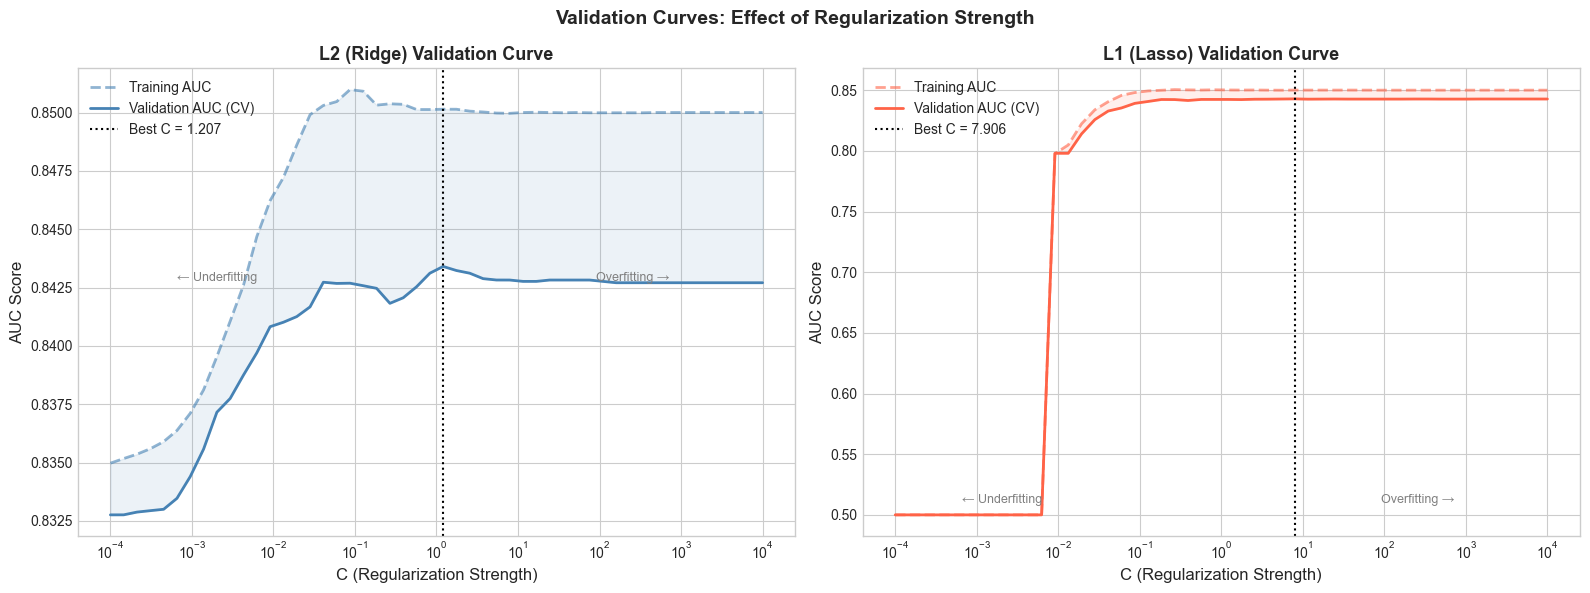

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, train_s, val_s, best_C, title, color in zip(
    axes,
    [train_scores_l2, train_scores_l1],
    [val_scores_l2, val_scores_l1],
    [best_C_l2, best_C_l1],
    ['L2 (Ridge) Validation Curve', 'L1 (Lasso) Validation Curve'],
    ['steelblue', 'tomato']
):
    ax.semilogx(C_values, train_s, '--', color=color, alpha=0.6, label='Training AUC', linewidth=2)
    ax.semilogx(C_values, val_s, '-', color=color, label='Validation AUC (CV)', linewidth=2)
    ax.axvline(x=best_C, color='black', linestyle=':', linewidth=1.5,
               label=f'Best C = {best_C:.3f}')
    ax.fill_between(C_values, train_s, val_s, alpha=0.1, color=color)
    ax.set_xlabel('C (Regularization Strength)', fontsize=12)
    ax.set_ylabel('AUC Score', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.annotate('← Underfitting', xy=(C_values[5], min(val_s)+0.01),
                fontsize=9, color='gray')
    ax.annotate('Overfitting →', xy=(C_values[-8], min(val_s)+0.01),
                fontsize=9, color='gray', ha='right')

plt.suptitle('Validation Curves: Effect of Regularization Strength', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Tuned Models with Optimal C

In [17]:
# Tuned L2
model_l2_tuned = LogisticRegression(penalty='l2', C=best_C_l2, solver='lbfgs',
                                     max_iter=1000, random_state=42)
model_l2_tuned.fit(X_train_scaled, y_train)
y_pred_l2t = model_l2_tuned.predict(X_test_scaled)
y_prob_l2t = model_l2_tuned.predict_proba(X_test_scaled)[:, 1]

# Tuned L1
model_l1_tuned = LogisticRegression(penalty='l1', C=best_C_l1, solver='liblinear',
                                     max_iter=1000, random_state=42)
model_l1_tuned.fit(X_train_scaled, y_train)
y_pred_l1t = model_l1_tuned.predict(X_test_scaled)
y_prob_l1t = model_l1_tuned.predict_proba(X_test_scaled)[:, 1]

print(f'Tuned L2 (C={best_C_l2:.4f}) — Test AUC: {roc_auc_score(y_test, y_prob_l2t):.4f}, Accuracy: {accuracy_score(y_test, y_pred_l2t):.4f}')
print(f'Tuned L1 (C={best_C_l1:.4f}) — Test AUC: {roc_auc_score(y_test, y_prob_l1t):.4f}, Accuracy: {accuracy_score(y_test, y_pred_l1t):.4f}')

Tuned L2 (C=1.2068) — Test AUC: 0.8130, Accuracy: 0.7078
Tuned L1 (C=7.9060) — Test AUC: 0.8130, Accuracy: 0.7078


## 9. Coefficient Comparison Across Models

Visualizing how regularization affects the magnitude of each feature's coefficient.

In [18]:
coef_data = pd.DataFrame({
    'Feature': FEATURES,
    'No Reg (C=1e9)': model_no_reg.coef_[0],
    'L2 (C=1.0)': model_l2.coef_[0],
    f'L2 Tuned (C={best_C_l2:.2f})': model_l2_tuned.coef_[0],
    'L1 (C=1.0)': model_l1.coef_[0],
    f'L1 Tuned (C={best_C_l1:.2f})': model_l1_tuned.coef_[0],
})

print('Coefficient Comparison:')
print(coef_data.set_index('Feature').round(4).to_string())

Coefficient Comparison:
                          No Reg (C=1e9)  L2 (C=1.0)  L2 Tuned (C=1.21)  L1 (C=1.0)  L1 Tuned (C=7.91)
Feature                                                                                               
Pregnancies                       0.3861      0.3775             0.3789      0.3707             0.3838
Glucose                           1.2068      1.1825             1.1866      1.1767             1.2030
BloodPressure                    -0.0504     -0.0441            -0.0451     -0.0264            -0.0475
SkinThickness                     0.0217      0.0282             0.0271      0.0141             0.0205
Insulin                          -0.0761     -0.0662            -0.0678     -0.0519            -0.0731
BMI                               0.7056      0.6887             0.6915      0.6819             0.7027
DiabetesPedigreeFunction          0.2368      0.2334             0.2339      0.2240             0.2350
Age                               0.1460      0.1

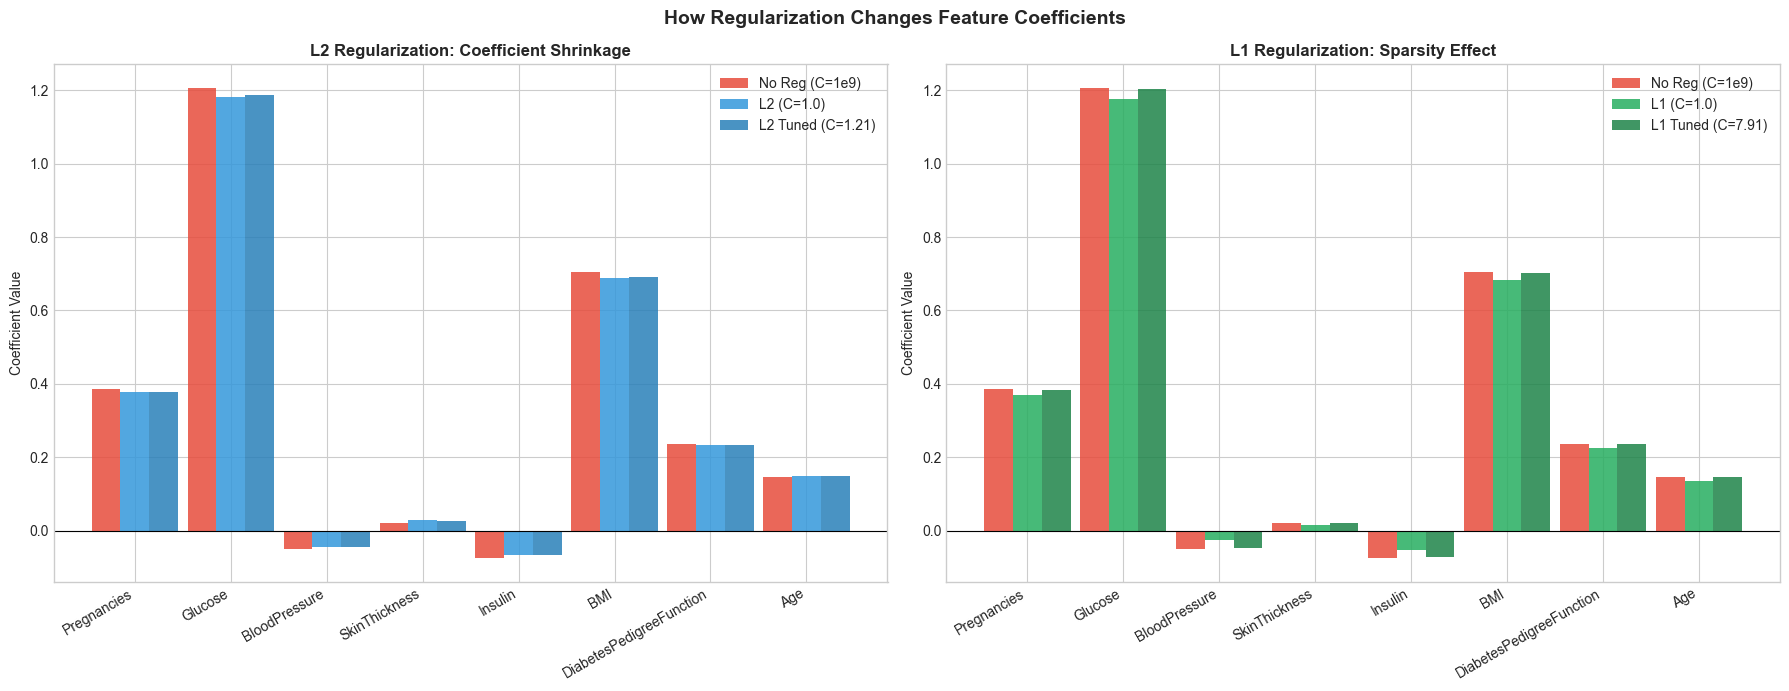

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# L2 coefficient shrinkage
x = np.arange(len(FEATURES))
width = 0.3

axes[0].bar(x - width, model_no_reg.coef_[0], width, label='No Reg (C=1e9)', color='#E74C3C', alpha=0.85)
axes[0].bar(x,         model_l2.coef_[0],     width, label='L2 (C=1.0)',      color='#3498DB', alpha=0.85)
axes[0].bar(x + width, model_l2_tuned.coef_[0], width, label=f'L2 Tuned (C={best_C_l2:.2f})', color='#2980B9', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(FEATURES, rotation=30, ha='right', fontsize=10)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('L2 Regularization: Coefficient Shrinkage', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Coefficient Value')
axes[0].legend()

# L1 coefficient sparsity
axes[1].bar(x - width, model_no_reg.coef_[0], width, label='No Reg (C=1e9)', color='#E74C3C', alpha=0.85)
axes[1].bar(x,         model_l1.coef_[0],     width, label='L1 (C=1.0)',      color='#27AE60', alpha=0.85)
axes[1].bar(x + width, model_l1_tuned.coef_[0], width, label=f'L1 Tuned (C={best_C_l1:.2f})', color='#1E8449', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(FEATURES, rotation=30, ha='right', fontsize=10)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('L1 Regularization: Sparsity Effect', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Coefficient Value')
axes[1].legend()

plt.suptitle('How Regularization Changes Feature Coefficients', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. ROC Curve Comparison

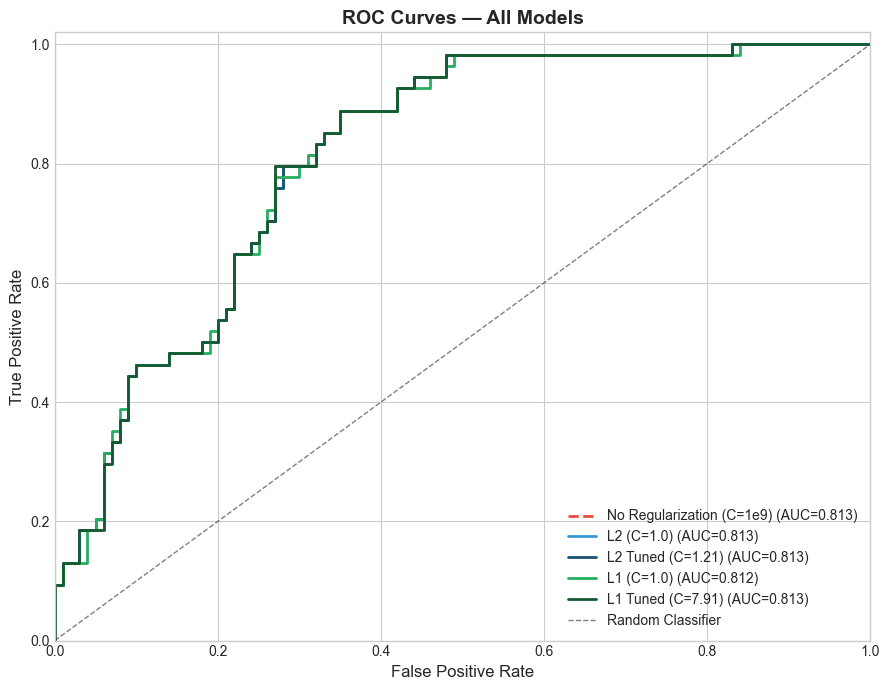

In [20]:
fig, ax = plt.subplots(figsize=(9, 7))

models_to_plot = [
    (y_prob_no_reg, 'No Regularization (C=1e9)', '#E74C3C', '--'),
    (y_prob_l2,     'L2 (C=1.0)',                '#3498DB', '-'),
    (y_prob_l2t,    f'L2 Tuned (C={best_C_l2:.2f})', '#1A5276', '-'),
    (y_prob_l1,     'L1 (C=1.0)',                '#27AE60', '-'),
    (y_prob_l1t,    f'L1 Tuned (C={best_C_l1:.2f})', '#145A32', '-'),
]

for probs, label, color, ls in models_to_plot:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, linestyle=ls, color=color, linewidth=2, label=f'{label} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

## 11. Final Results Summary

In [21]:
results = {
    'Model': [
        'No Regularization (C=1e9)',
        'L2 Default (C=1.0)',
        f'L2 Tuned (C={best_C_l2:.3f})',
        'L1 Default (C=1.0)',
        f'L1 Tuned (C={best_C_l1:.3f})'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_no_reg),
        accuracy_score(y_test, y_pred_l2),
        accuracy_score(y_test, y_pred_l2t),
        accuracy_score(y_test, y_pred_l1),
        accuracy_score(y_test, y_pred_l1t)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_prob_no_reg),
        roc_auc_score(y_test, y_prob_l2),
        roc_auc_score(y_test, y_prob_l2t),
        roc_auc_score(y_test, y_prob_l1),
        roc_auc_score(y_test, y_prob_l1t)
    ],
    'Non-zero Coefs': [
        (model_no_reg.coef_[0] != 0).sum(),
        (model_l2.coef_[0] != 0).sum(),
        (model_l2_tuned.coef_[0] != 0).sum(),
        (model_l1.coef_[0] != 0).sum(),
        (model_l1_tuned.coef_[0] != 0).sum()
    ]
}

results_df = pd.DataFrame(results)
results_df['Accuracy'] = results_df['Accuracy'].round(4)
results_df['AUC-ROC'] = results_df['AUC-ROC'].round(4)

print('=== Final Results ===')
print(results_df.to_string(index=False))
print(f'\nTotal features: {len(FEATURES)}')

=== Final Results ===
                    Model  Accuracy  AUC-ROC  Non-zero Coefs
No Regularization (C=1e9)    0.7078   0.8131               8
       L2 Default (C=1.0)    0.7078   0.8130               8
       L2 Tuned (C=1.207)    0.7078   0.8130               8
       L1 Default (C=1.0)    0.7013   0.8120               8
       L1 Tuned (C=7.906)    0.7078   0.8130               8

Total features: 8


---
## 🏋️ Exercises

Complete the following exercises to solidify your understanding of regularization.

---

### Exercise 1 — Elastic Net Regularization

Implement an Elastic Net regularized logistic regression model.

- Use `penalty='elasticnet'` and `solver='saga'`
- Try `l1_ratio` values of 0.1, 0.5, and 0.9
- Report accuracy and AUC for each
- What `l1_ratio` performs best?

**Starter code:**
```python
from sklearn.linear_model import LogisticRegression

for ratio in [0.1, 0.5, 0.9]:
    model_en = LogisticRegression(
        penalty='elasticnet',
        C=1.0,
        solver='saga',
        l1_ratio=ratio,    # mixing parameter: 0 = L2, 1 = L1
        max_iter=2000,
        random_state=42
    )
    # TODO: fit, predict, report metrics
```

In [22]:
# ✏️ Exercise 1 — Your solution here
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# Elastic Net mixes L1 and L2 penalties:
#   loss += C⁻¹ × [l1_ratio × |β| + (1 - l1_ratio) × β²]
# l1_ratio=0 → pure L2 (Ridge)
# l1_ratio=1 → pure L1 (Lasso)
# Values in between → blend of both

results = []

for ratio in [0.1, 0.5, 0.9]:
    model_en = LogisticRegression(
        penalty='elasticnet',
        C=1.0,
        solver='saga',          # required — only saga supports elasticnet
        l1_ratio=ratio,
        max_iter=2000,          # saga converges slower, give it more iterations
        random_state=42
    )

    model_en.fit(X_train_scaled, y_train)

    y_pred = model_en.predict(X_test_scaled)
    y_prob = model_en.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    n_nonzero = (model_en.coef_[0] != 0).sum()

    results.append({'ratio': ratio, 'acc': acc, 'auc': auc, 'nonzero': n_nonzero})
    print(f"l1_ratio={ratio} → Accuracy: {acc:.4f}, AUC: {auc:.4f}, Non-zero coefs: {n_nonzero}/8")

l1_ratio=0.1 → Accuracy: 0.7013, AUC: 0.8130, Non-zero coefs: 8/8
l1_ratio=0.5 → Accuracy: 0.7013, AUC: 0.8120, Non-zero coefs: 8/8
l1_ratio=0.9 → Accuracy: 0.6948, AUC: 0.8122, Non-zero coefs: 8/8


---
### Exercise 2 — The Effect of C on Sparsity

Investigate how the number of non-zero L1 coefficients changes as C varies.

- Use C values: `[0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]`
- For each C, fit an L1 model and count non-zero coefficients
- Plot: x-axis = log(C), y-axis = number of non-zero coefficients
- What minimum C is needed to keep all 8 features?

**Questions to answer:**
1. Which feature is eliminated last (i.e., most important)?
2. Which feature is eliminated first (i.e., least important)?
3. Does this match the correlation heatmap from Section 3?

C= 0.001 → 0/8 features active  [0. 0. 0. 0. 0. 0. 0. 0.]
C= 0.010 → 1/8 features active  [0.    0.333 0.    0.    0.    0.    0.    0.   ]
C= 0.100 → 5/8 features active  [0.272 1.025 0.    0.    0.    0.542 0.129 0.084]
C= 0.500 → 8/8 features active  [ 0.356  1.148 -0.003  0.007 -0.028  0.659  0.212  0.126]
C= 1.000 → 8/8 features active  [ 0.371  1.177 -0.026  0.014 -0.052  0.682  0.224  0.136]
C= 5.000 → 8/8 features active  [ 0.383  1.201 -0.046  0.02  -0.071  0.701  0.234  0.144]
C=10.000 → 8/8 features active  [ 0.384  1.204 -0.048  0.021 -0.074  0.703  0.235  0.145]
C=100.000 → 8/8 features active  [ 0.386  1.207 -0.05   0.021 -0.076  0.706  0.236  0.146]


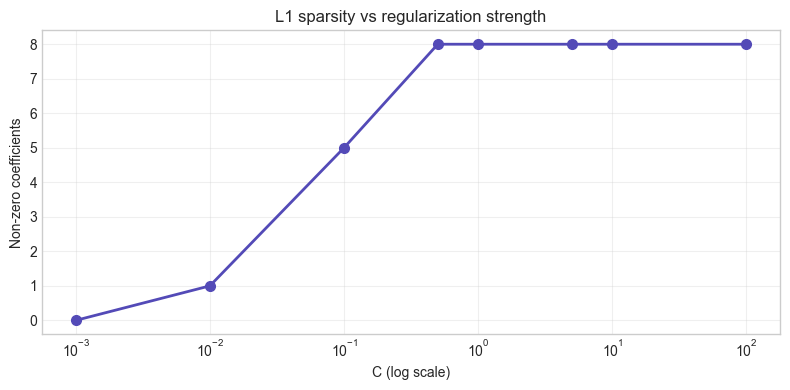

C=0.001: []
C=0.01: ['Glucose']
C=0.1: ['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']
C=0.5: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
C=1.0: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
C=5.0: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
C=10.0: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
C=100.0: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [23]:
# ✏️ Exercise 2 — Your solution here

C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]
nonzero_counts = []
coef_history = []   # store all coefs to answer the questions below

for C in C_values:
    model = LogisticRegression(
        penalty='l1',
        C=C,
        solver='liblinear',
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    coefs = model.coef_[0]
    n = (coefs != 0).sum()
    nonzero_counts.append(n)
    coef_history.append(coefs)
    print(f"C={C:6.3f} → {n}/8 features active  {coefs.round(3)}")

# Plot: x = log(C), y = non-zero coefficient count
plt.figure(figsize=(8, 4))
plt.semilogx(C_values, nonzero_counts, 'o-', color='#534AB7', linewidth=2, markersize=7)
plt.xlabel('C (log scale)')
plt.ylabel('Non-zero coefficients')
plt.title('L1 sparsity vs regularization strength')
plt.yticks(range(0, 9))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Which feature survives longest (eliminated last)?
# Scan coef_history from low C upward — last feature to become non-zero
for i, C in enumerate(C_values):
    active = [FEATURES[j] for j, v in enumerate(coef_history[i]) if v != 0]
    print(f"C={C}: {active}")

---
### Exercise 3 — Polynomial Features + Regularization

Adding polynomial features increases model expressiveness but also risk of overfitting. Investigate how regularization controls this.

- Create degree-2 polynomial features using `PolynomialFeatures(degree=2)`
- Compare three scenarios on the polynomial features:
  - (a) No regularization (large C)
  - (b) L2 with default C=1.0
  - (c) L2 with tuned C (use cross-validation)
- Report training AUC and test AUC for each
- Explain why the gap between training and test AUC is larger without regularization

**Hint:** Use a Pipeline to chain PolynomialFeatures → StandardScaler → LogisticRegression

```python
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(...))
])
```

In [24]:
# ✏️ Exercise 3 — Your solution here
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# Degree-2 polynomial on 8 features produces:
# 8 original + 8 squared + 28 cross-terms + 1 bias = 44 features
# More features = more overfitting risk without regularization

scenarios = [
    {
        'name': '(a) No regularization',
        'clf': LogisticRegression(penalty='l2', C=1e9, solver='lbfgs',
                                   max_iter=5000, random_state=42)
    },
    {
        'name': '(b) L2 default C=1.0',
        'clf': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                                   max_iter=5000, random_state=42)
    },
    {
        'name': '(c) L2 tuned C (CV)',
        'clf': LogisticRegressionCV(penalty='l2', solver='lbfgs',
                                     cv=5, scoring='roc_auc',
                                     max_iter=5000, random_state=42)
    },
]

for s in scenarios:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('clf',    s['clf'])
    ])

    pipe.fit(X_train, y_train)   # use raw X_train — pipeline handles scaling

    train_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test,  pipe.predict_proba(X_test)[:, 1])
    gap = train_auc - test_auc

    print(f"{s['name']}")
    print(f"  Train AUC: {train_auc:.4f}  Test AUC: {test_auc:.4f}  Gap: {gap:.4f}\n")


(a) No regularization
  Train AUC: 0.8833  Test AUC: 0.8085  Gap: 0.0748

(b) L2 default C=1.0
  Train AUC: 0.8783  Test AUC: 0.8306  Gap: 0.0477

(c) L2 tuned C (CV)
  Train AUC: 0.8710  Test AUC: 0.8313  Gap: 0.0397



---
### Exercise 4 — Class Imbalance + Regularization

The Pima dataset has ~35% positive cases — moderate imbalance. Explore whether `class_weight='balanced'` interacts with regularization.

- Fit four models:
  - L2, no class weighting
  - L2, `class_weight='balanced'`
  - L1, no class weighting
  - L1, `class_weight='balanced'`
- Compare accuracy, recall for class 1 (diabetic), and AUC
- Which combination maximizes diabetic recall? Which maximizes overall accuracy?
- In a medical screening context, which metric should you prioritize and why?

In [25]:
# ✏️ Exercise 4 — Your solution here
models = [
    {
        'name': 'L2, no weighting',
        'clf': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                                   max_iter=1000, random_state=42)
    },
    {
        'name': 'L2, balanced',
        'clf': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                                   class_weight='balanced',
                                   max_iter=1000, random_state=42)
    },
    {
        'name': 'L1, no weighting',
        'clf': LogisticRegression(penalty='l1', C=1.0, solver='liblinear',
                                   max_iter=1000, random_state=42)
    },
    {
        'name': 'L1, balanced',
        'clf': LogisticRegression(penalty='l1', C=1.0, solver='liblinear',
                                   class_weight='balanced',
                                   max_iter=1000, random_state=42)
    },
]

for m in models:
    m['clf'].fit(X_train_scaled, y_train)
    y_pred = m['clf'].predict(X_test_scaled)
    y_prob = m['clf'].predict_proba(X_test_scaled)[:, 1]

    report = classification_report(y_test, y_pred,
                                   target_names=['Non-diabetic', 'Diabetic'],
                                   output_dict=True)

    m['acc']    = accuracy_score(y_test, y_pred)
    m['auc']    = roc_auc_score(y_test, y_prob)
    m['recall1'] = report['Diabetic']['recall']   # recall for class 1
    m['prec1']  = report['Diabetic']['precision']

    print(f"{m['name']:25s} Acc={m['acc']:.3f}  AUC={m['auc']:.3f}  Diabetic recall={m['recall1']:.3f}")

L2, no weighting          Acc=0.708  AUC=0.813  Diabetic recall=0.500
L2, balanced              Acc=0.734  AUC=0.813  Diabetic recall=0.704
L1, no weighting          Acc=0.701  AUC=0.812  Diabetic recall=0.500
L1, balanced              Acc=0.727  AUC=0.811  Diabetic recall=0.704


---
### 🔑 Key Takeaways

After completing this lab, you should be able to:

- ✅ Apply L1 and L2 regularization to logistic regression in scikit-learn
- ✅ Tune the regularization strength `C` using cross-validation and validation curves
- ✅ Explain the difference between L1 (sparsity) and L2 (shrinkage) penalties
- ✅ Understand that features must be scaled before regularization
- ✅ Choose the right solver for each penalty type
- ✅ Interpret ROC curves and AUC to compare model performance

---
*Lab created for educational purposes. Dataset: Pima Indians Diabetes Database (Smith et al., 1988).*